In [12]:
from scipy.io import loadmat
import numpy as np

dados = loadmat('Pneumático_G4.mat')

print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Degrau', 'Saida', 't', 'unidade_saida', 'parametros', 'descricao'])


In [13]:
t = dados['t'].squeeze()
entrada = dados['Degrau'].squeeze()
saida = dados['Saida'].squeeze()

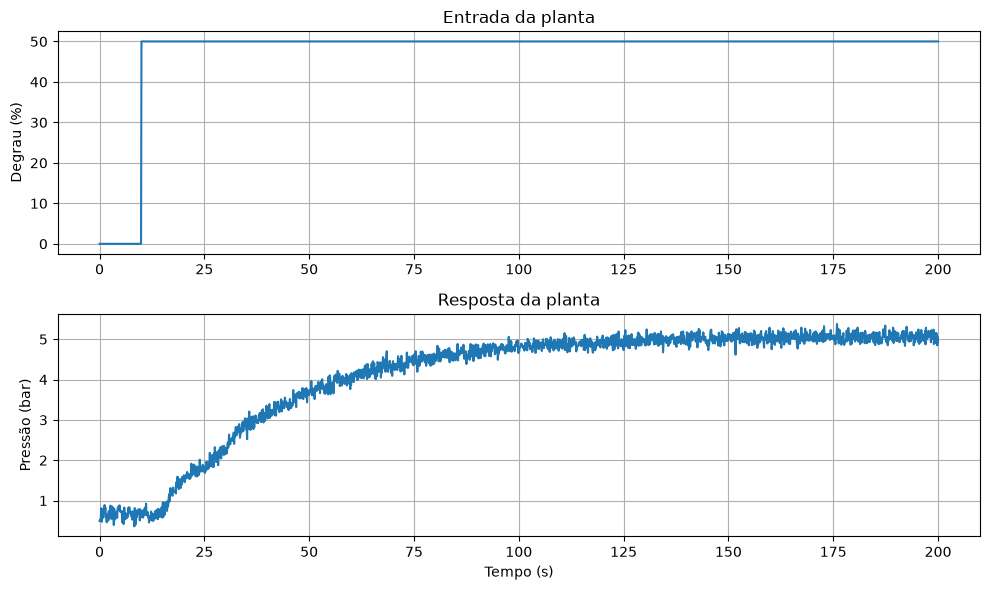

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, entrada)
plt.grid()
plt.ylabel('Degrau (%)')
plt.title('Entrada da planta')

plt.subplot(2, 1, 2)
plt.plot(t, saida)
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Resposta da planta')

plt.tight_layout()
plt.show()

### método de identificação de smith

In [15]:
# pegando as médias dos 10 valores iniciais e finais
n = 10
u0 = np.mean(entrada[:n])
uf = np.mean(entrada[-n:])


y0 = np.mean(saida[:n])
yf = np.mean(saida[-n:])

delta_u = uf - u0
delta_y = yf - y0

K = delta_y / delta_u

# Níveis de Smith
y_t1 = y0 + 0.283 * delta_y
y_t2 = y0 + 0.632 * delta_y

t1 = t[np.where(saida >= y_t1)[0][0]]
t2 = t[np.where(saida >= y_t2)[0][0]]

tau = 1.5 * (t2 - t1)
theta = t2 - tau

print(K)
print(tau)
print(theta)

0.08814492968715427
29.700000000000003
12.0


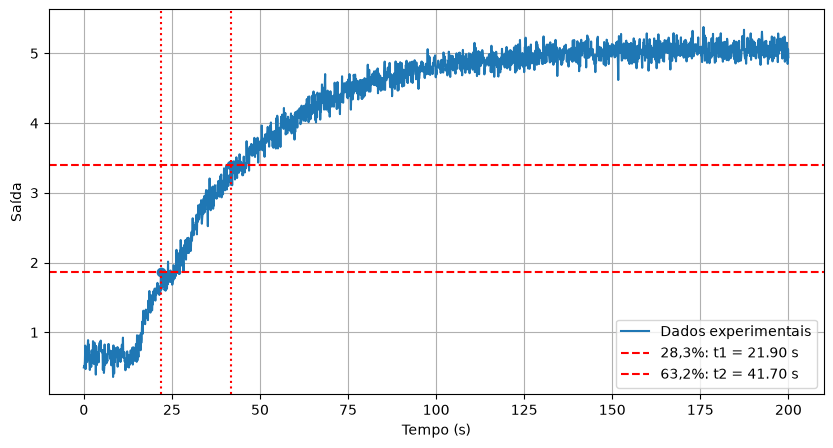

In [16]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1, linestyle='--',
            label=f'28,3%: t1 = {t1:.2f} s',c='r')

plt.axhline(y_t2, linestyle='--',
            label=f'63,2%: t2 = {t2:.2f} s',c='r')

plt.axvline(t1, linestyle=':',c='r')
plt.axvline(t2, linestyle=':',c='r')

plt.scatter([t1, t2], [y_t1, y_t2])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### método de identificação de Sundaresan


In [17]:
# Níveis de Sundaresan
y_t1_sun = y0 + 0.353 * delta_y
y_t2_sun = y0 + 0.853 * delta_y

t1_sun = t[np.where(saida >= y_t1_sun)[0][0]]
t2_sun = t[np.where(saida >= y_t2_sun)[0][0]]

tau_sun = (2/3) * (t2_sun - t1_sun)
theta_sun = 1.3 * t1_sun - 0.29 * t2_sun

print(K)
print(tau_sun)
print(theta_sun)

0.08814492968715427
24.933333333333337
15.717000000000006


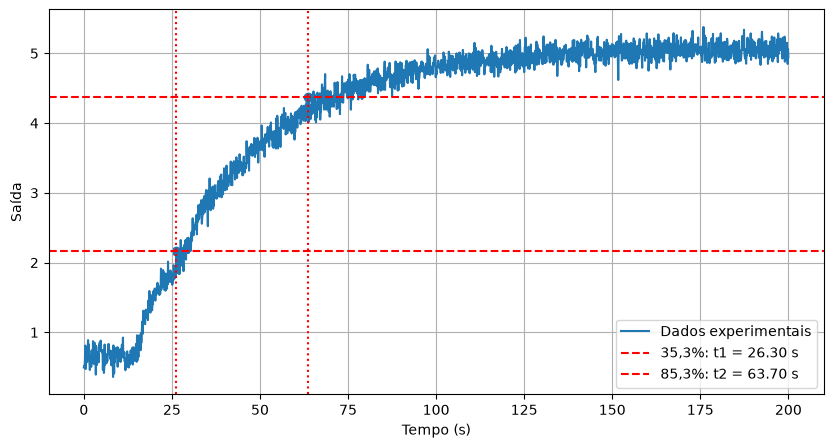

In [18]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1_sun, linestyle='--',
            label=f'35,3%: t1 = {t1_sun:.2f} s',c='r')

plt.axhline(y_t2_sun, linestyle='--',
            label=f'85,3%: t2 = {t2_sun:.2f} s',c='r')

plt.axvline(t1_sun, linestyle=':',c='r')
plt.axvline(t2_sun, linestyle=':',c='r')

plt.scatter([t1_sun, t2_sun], [y_t1_sun, y_t2_sun])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### Resposta estimada pelo método de Smith

In [ ]:
saida_smith = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta:
        saida_smith[i] = y0
    else:
        saida_smith[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta) / tau))

### Resposta estimada pelo método de Sundaresan

In [ ]:
saida_sundaresan = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta_sun:
        saida_sundaresan[i] = y0
    else:
        saida_sundaresan[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta_sun) / tau_sun))

### Comparação dos métodos de identificação


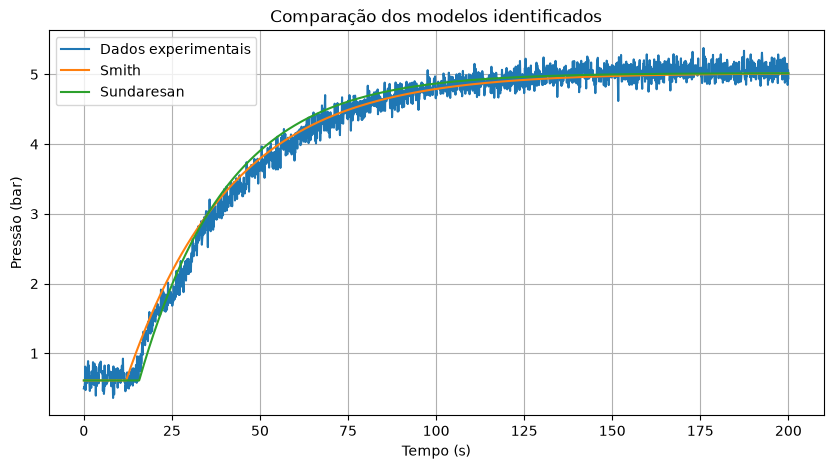

In [ ]:

plt.figure(figsize=(10, 5))

plt.plot(t, saida, label='Dados experimentais')

plt.plot(t, saida_smith, label='Smith')

plt.plot(t,saida_sundaresan, label='Sundaresan')

plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Comparação dos modelos identificados')

plt.grid()
plt.legend()

plt.show()

### Cálculo do RMSE

In [ ]:
rmse_smith = np.sqrt(np.mean((saida - saida_smith) ** 2))

rmse_sundaresan = np.sqrt(np.mean((saida - saida_sundaresan) ** 2))

print("RMSE Smith:", rmse_smith)
print("RMSE Sundaresan:", rmse_sundaresan)

RMSE Smith: 0.14722527590806803
RMSE Sundaresan: 0.15869647925131977
